In [2]:
import os
import requests
import torch

# 1. Download Tiny Shakespeare dataset
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
if not os.path.exists("input.txt"):
    with open("input.txt", "w", encoding="utf-8") as f:
        f.write(requests.get(url).text)

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

# 2. Build Character Vocabulary Lookups
chars = sorted(list(set(text)))
vocab_size = len(chars)  # This will be exactly 65
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]           # Encoder: string to integers
decode = lambda l: "".join([itos[i] for i in l])  # Decoder: integers to string

# 3.  Train and Validation Splits (90/10 Split)
data = torch.tensor(encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data = data[:n_train]
val_data = data[n_train:]

print(f"Dataset loaded. Total characters: {len(data)}")
print(f"Vocabulary size: {vocab_size}")
print(f"Train samples: {len(train_data)} | Val samples: {len(val_data)}")

Dataset loaded. Total characters: 1115394
Vocabulary size: 65
Train samples: 1003854 | Val samples: 111540


In [15]:
%%writefile models.py
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalMultiHeadAttention(nn.Module):

    def __init__(self, d_model, n_heads, max_seq_len):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divide by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        #  Projections from X to Q, K, V using basic Linear layers
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        #  lower-triangular mask: 1s on diagonal and below,0s above

        self.register_buffer("mask", torch.tril(torch.ones(max_seq_len, max_seq_len)))

    def forward(self, x):
        B, T, C = x.shape  # B=Batch size, T=Sequence length, C=d_model


        # projecting to Q,K,V
        q= self.q_proj(x)
        k=self.k_proj(x)
        v = self.v_proj(x)

        # Split of multiple heads and transpose
        q = q.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # Calculate raw scaled attention scores Q muliplied by K:
        #k.transpose(-2, -1) changes shape from [B, H, T, d_k] to [B, H, d_k, T]

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)

        #  Apply masking: replace 0s in the lower triangle mask with -inf
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float('-inf'))

        #  Softmax turns -inf into exactly 0 attention weight
        attn_weights = F.softmax(scores, dim=-1)

        # Final contextual output calculation
        out = attn_weights @ v  # [B, H, T, d_model]

        # Concatenate heads back together cleanly to reshape back to [B, T, d_model]
        out = out.transpose(1, 2).contiguous().view(B, T, self.d_model)

        return self.out_proj(out)

class PositionWiseFeedForward(nn.Module):
    """
    Two-layer MLP processing positions identically across sequences using GELU.
    """
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ff)
        self.w2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        # Math calculation: GELU(xW1 + b1)W2 + b2
        return self.w2(F.gelu(self.w1(x)))

Overwriting models.py


In [16]:
%%writefile -a models.py

class TransformerBlock(nn.Module):
    """
    A single Transformer block implementing Pre-Layer Normalization (Pre-LN).
    """
    def __init__(self, d_model, n_heads, d_ff, max_seq_len):
        super().__init__()
        # Every block contains 2 sub-layers
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalMultiHeadAttention(d_model, n_heads, max_seq_len)

        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = PositionWiseFeedForward(d_model, d_ff)

    def forward(self, x):
        # Sub-Layer 1: Pre-LN -> Attention -> Residual Addition
        x = x + self.attn(self.ln1(x))
        # Sub-Layer 2: Pre-LN -> FFN -> Residual Addition
        x = x + self.ffn(self.ln2(x))
        return x

class DecoderTransformer(nn.Module):
    """
    Full Decoder-Only GPT-style Autoregressive Transformer with Weight Tying.
    """
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, max_seq_len):
        super().__init__()
        self.max_seq_len = max_seq_len

        # 1. Token and Learnable Position Embeddings
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(max_seq_len, d_model)

        # 2. Stack of custom Transformer blocks
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ff, max_seq_len) for _ in range(n_layers)
        ])

        # 3. Final Pre-output normalization
        self.ln_f = nn.LayerNorm(d_model)

        # 4. Language Model Head
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)

        # STRICT REQUIREMENT: Weight-Tied LM Head
        self.lm_head.weight = self.token_embedding.weight

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.max_seq_len, f"Cannot forward sequence of length {T}, max is {self.max_seq_len}"

        # Construct embeddings along the residual highway stream
        tok_emb = self.token_embedding(idx) # [B, T, d_model]
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device)
        pos_emb = self.position_embedding(pos) # [T, d_model]

        x = tok_emb + pos_emb # [B, T, d_model]

        # Pass data forward through the stack of layers
        for layer in self.layers:
            x = layer(x)

        x = self.ln_f(x)
        logits = self.lm_head(x) # [B, T, vocab_size]

        loss = None
        if targets is not None:
            # Reshape logits and targets to meet PyTorch's cross_entropy shape expectations
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

Appending to models.py


In [17]:
from models import DecoderTransformer
import torch
import importlib
import models # Import the module first if not already imported

def run_basic_checks():
    print(" Running Simple Model checking ")

    # 1. Setup small dummy variables
    batch_size = 4
    sequence_len = 10
    vocab_size = 65

    # Reload the models module to ensure the latest changes are used
    importlib.reload(models)

    model = DecoderTransformer(
        vocab_size=vocab_size,
        d_model=64,
        n_heads=2,
        d_ff=256,
        n_layers=2,
        max_seq_len=128
    )

    # 2. Basic Dimension Check
    # Create  input text tokens
    dummy_input = torch.randint(0, vocab_size, (batch_size, sequence_len))

    # Forward pass
    logits, loss = model(dummy_input, targets=dummy_input)

    print(f"Input Shape:  {list(dummy_input.shape)}")
    print(f"Logits Shape: {list(logits.shape)}")

    # Assert that the output matches [Batch, Sequence_Length, Vocab_Size]
    assert logits.shape == (batch_size, sequence_len, vocab_size), "Output dimensions are incorrect"
    print("[SUCCESS] Dimension verification test passed.")

    # 3. Visual Causal Mask Check
    #  first 4x4 corner of the mask  verify it works visually
    print("\nVerifying Causal Mask Structure (Lower Triangular):")
    # mask stored inside our custom attention layer of the first block
    mask_sample = model.layers[0].attn.mask[:4, :4]
    print(mask_sample)

    print("end")

# Run the simplified checks
run_basic_checks()

 Running Simple Model checking 
Input Shape:  [4, 10]
Logits Shape: [4, 10, 65]
[SUCCESS] Dimension verification test passed.

Verifying Causal Mask Structure (Lower Triangular):
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])
end


In [18]:
%%writefile train_scaling.py
import torch
import numpy as np
from models import DecoderTransformer

def get_batch(data, batch_size, block_size, device):
    """
    Custom data pipeline to pack raw tokens into batches of X, Y.
    """
    ix = torch.randint(0, len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

def count_non_embedding_params(model):
    """
    Programmatic validation excluding token embeddings and language model heads.
    """
    return sum(p.numel() for name, p in model.named_parameters()
               if 'token_embedding' not in name and 'position_embedding' not in name and 'lm_head' not in name)

@torch.no_grad()
def estimate_loss(model, data, batch_size, block_size, eval_iters, device):
    """
    Tracks validation loss limits over controlled evaluations[cite: 49, 54].
    """
    model.eval()
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
        X, Y = get_batch(data, batch_size, block_size, device)
        _, loss = model(X, Y)
        losses[k] = loss.item()
    model.train()
    return losses.mean().item()

Writing train_scaling.py


In [19]:
from train_scaling import get_batch, count_non_embedding_params
from models import DecoderTransformer
import torch
import torch.optim as optim

print("--- Running Overfitting Verification Test ---")
device = "cuda" if torch.cuda.is_available() else "cpu"

# Instantiate a small diagnostic network
diagnostic_model = DecoderTransformer(
    vocab_size=65, d_model=64, n_heads=2, d_ff=256, n_layers=2, max_seq_len=128
).to(device)

# Grab a single permanent batch of text
fixed_X, fixed_Y = get_batch(train_data, batch_size=2, block_size=32, device=device)

# Overfit using standard AdamW
optimizer = optim.AdamW(diagnostic_model.parameters(), lr=1e-3)

diagnostic_model.train()
print("Training on single batch for 200 optimization cycles...")
for step in range(200):
    optimizer.zero_grad()
    logits, loss = diagnostic_model(fixed_X, fixed_Y)
    loss.backward()
    optimizer.step()

    if step % 40 == 0 or step == 199:
        print(f"Step {step:3d} | Cross-Entropy Loss: {loss.item():.4f}")

assert loss.item() < 0.1, "Model failed to overfit a single batch. Check architecture math!"
print("[PASS] Overfitting check passed. Core structural completeness achieved.\n")

--- Running Overfitting Verification Test ---
Training on single batch for 200 optimization cycles...
Step   0 | Cross-Entropy Loss: 41.5522
Step  40 | Cross-Entropy Loss: 0.4592
Step  80 | Cross-Entropy Loss: 0.0068
Step 120 | Cross-Entropy Loss: 0.0025
Step 160 | Cross-Entropy Loss: 0.0016
Step 199 | Cross-Entropy Loss: 0.0011
[PASS] Overfitting check passed. Core structural completeness achieved.



In [20]:
%%writefile -a train_scaling.py

import os
import json

def run_sweeps(train_data, val_data, vocab_size, device, is_test_run=True):
    # If is_test_run is True, we do a quick check of 100 steps.
    # Change to False for the final 3000 step run required by your assignment!
    total_steps = 100 if is_test_run else 3000
    eval_interval = 20 if is_test_run else 200
    eval_iters = 5 if is_test_run else 50

    # Static global configurations
    block_size = 128
    batch_size = 32
    learning_rate = 1e-3

    print(f"Launching Sweeps (Mode: {'TEST RUN' if is_test_run else 'OFFICIAL SWEEP'}) ---")


    # SWEEP 1: Parameter Scaling Sweep

    print("\n Starting Sweep 1: Parameter Scaling ")
    param_configs = {
        "Tiny":   {"layers": 2, "d_model": 64,  "n_heads": 2, "d_ff": 256},
        "Small":  {"layers": 4, "d_model": 128, "n_heads": 4, "d_ff": 512},
        "Medium": {"layers": 6, "d_model": 256, "n_heads": 8, "d_ff": 1024}
    }

    parameter_sweep_results = {}

    for name, config in param_configs.items():
        print(f"Training {name} model scale...")
        model = DecoderTransformer(
            vocab_size=vocab_size,
            d_model=config["d_model"],
            n_heads=config["n_heads"],
            d_ff=config["d_ff"],
            n_layers=config["layers"],
            max_seq_len=block_size
        ).to(device)

        N = count_non_embedding_params(model)
        print(f"Model {name} counted non-embedding parameters N = {N}")

        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
        best_val_loss = float('inf')

        for step in range(total_steps):
            x, y = get_batch(train_data, batch_size, block_size, device)
            logits, loss = model(x, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % eval_interval == 0 or step == total_steps - 1:
                val_loss = estimate_loss(model, val_data, batch_size, block_size, eval_iters, device)
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                print(f"  Step {step}/{total_steps} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss:.4f}")

        parameter_sweep_results[name] = {"N": N, "loss": best_val_loss}


    # SWEEP 2: Data Scaling Sweep

    print("\n Starting Sweep 2: Data Scaling ")
    data_percentages = [0.10, 0.25, 0.50, 1.00]
    data_sweep_results = {}

    small_cfg = param_configs["Small"]

    for p in data_percentages:
        print(f"Training Small model on {int(p*100)}% of token dataset...")

        # Take a clean slice of the training tokens
        tokens_cutoff = int(p * len(train_data))
        subset_train_data = train_data[:tokens_cutoff]

        model = DecoderTransformer(
            vocab_size=vocab_size,
            d_model=small_cfg["d_model"],
            n_heads=small_cfg["n_heads"],
            d_ff=small_cfg["d_ff"],
            n_layers=small_cfg["layers"],
            max_seq_len=block_size
        ).to(device)

        D = tokens_cutoff
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
        best_val_loss = float('inf')

        for step in range(total_steps):
            x, y = get_batch(subset_train_data, batch_size, block_size, device)
            logits, loss = model(x, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % eval_interval == 0 or step == total_steps - 1:
                val_loss = estimate_loss(model, val_data, batch_size, block_size, eval_iters, device)
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                print(f"  Step {step}/{total_steps} | Val Loss: {val_loss:.4f}")

        data_sweep_results[int(p*100)] = {"D": D, "loss": best_val_loss}

    # Save results to a json file to be read by the plotting script
    sweep_output = {
        "parameter_sweep": parameter_sweep_results,
        "data_sweep": data_sweep_results
    }

    with open("sweep_results.json", "w") as f:
        json.dump(sweep_output, f, indent=4)
    print("\n[SUCCESS] Sweeps complete. Data written to sweep_results.json")

Appending to train_scaling.py


In [21]:
import train_scaling
import importlib
importlib.reload(train_scaling)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Run a quick test sweep (100 steps) to make sure there are no bugs!
train_scaling.run_sweeps(
    train_data=train_data,
    val_data=val_data,
    vocab_size=vocab_size,
    device=device,
    is_test_run=True  # Keeps it fast for testing
)

Launching Sweeps (Mode: TEST RUN) ---

 Starting Sweep 1: Parameter Scaling 
Training Tiny model scale...
Model Tiny counted non-embedding parameters N = 100096
  Step 0/100 | Train Loss: 42.6939 | Val Loss: 41.0665
  Step 20/100 | Train Loss: 10.5550 | Val Loss: 9.8759
  Step 40/100 | Train Loss: 4.9050 | Val Loss: 5.0659
  Step 60/100 | Train Loss: 4.1280 | Val Loss: 4.0901
  Step 80/100 | Train Loss: 3.5928 | Val Loss: 3.5561
  Step 99/100 | Train Loss: 3.2563 | Val Loss: 3.2294
Training Small model scale...
Model Small counted non-embedding parameters N = 793344
  Step 0/100 | Train Loss: 80.9197 | Val Loss: 69.4777
  Step 20/100 | Train Loss: 5.9176 | Val Loss: 5.9048
  Step 40/100 | Train Loss: 4.0789 | Val Loss: 4.1003
  Step 60/100 | Train Loss: 3.3929 | Val Loss: 3.5260
  Step 80/100 | Train Loss: 3.2270 | Val Loss: 3.2594
  Step 99/100 | Train Loss: 3.0618 | Val Loss: 3.1444
Training Medium model scale...
Model Medium counted non-embedding parameters N = 4739072
  Step 0/100 

In [22]:
%%writefile plot_scaling.py
import json
import numpy as np
import matplotlib.pyplot as plt

def generate_scaling_plots():
    # 1. Load results written by the training sweep
    if not open("sweep_results.json"):
        print("Error: sweep_results.json not found.")
        return

    with open("sweep_results.json", "r") as f:
        data = json.load(f)

    param_sweep = data["parameter_sweep"]
    data_sweep = data["data_sweep"]

    # 2. Extract values for Parameter Scaling
    N_vals = []
    L_N_vals = []
    for name, res in param_sweep.items():
        N_vals.append(res["N"])
        L_N_vals.append(res["loss"])

    log_N = np.log(N_vals)
    log_L_N = np.log(L_N_vals)

    # Find slope alpha_N using linear polyfit regression
    slope_N, intercept_N = np.polyfit(log_N, log_L_N, 1)
    alpha_N = -slope_N  # The formula has a minus sign, so we invert it

    # 3. Extract values for Data Scaling
    D_vals = []
    L_D_vals = []
    for pct, res in data_sweep.items():
        D_vals.append(res["D"])
        L_D_vals.append(res["loss"])

    log_D = np.log(D_vals)
    log_L_D = np.log(L_D_vals)

    # Find slope alpha_D using linear polyfit regression
    slope_D, intercept_D = np.polyfit(log_D, log_L_D, 1)
    alpha_D = -slope_D

    # Calculate the ultimate scaling ratio
    gamma = alpha_N / alpha_D if alpha_D != 0 else 0

    print("--- Empirical Scaling Law Metrics Fit ---")
    print(f"Calculated Alpha_N (Parameter Exponent): {alpha_N:.4f}")
    print(f"Calculated Alpha_D (Data Exponent):      {alpha_D:.4f}")
    print(f"Calculated Scaling Ratio (Gamma):        {gamma:.4f}")

    # 4. Generate the required log-log validation scaling plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Left subplot: Parameter scaling line fit
    ax1.scatter(N_vals, L_N_vals, color='red', label='Experimental Data', zorder=5)
    fit_N_loss = np.exp(intercept_N) * (np.array(N_vals) ** slope_N)
    ax1.plot(N_vals, fit_N_loss, color='blue', linestyle='--', label=f'Fit Line (α_N={alpha_N:.3f})')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Non-Embedding Parameters (N)')
    ax1.set_ylabel('Validation Loss (L)')
    ax1.set_title('Loss vs Model Parameters (N)')
    ax1.grid(True, which="both", ls="-")
    ax1.legend()

    # Right subplot: Data scaling line fit
    ax2.scatter(D_vals, L_D_vals, color='orange', label='Experimental Data', zorder=5)
    fit_D_loss = np.exp(intercept_D) * (np.array(D_vals) ** slope_D)
    ax2.plot(D_vals, fit_D_loss, color='green', linestyle='--', label=f'Fit Line (α_D={alpha_D:.3f})')
    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Dataset Size in Tokens (D)')
    ax2.set_ylabel('Validation Loss (L)')
    ax2.set_title('Loss vs Training Dataset Size (D)')
    ax2.grid(True, which="both", ls="-")
    ax2.legend()

    plt.suptitle(f"Empirical Scaling Laws (Ratio Gamma = {gamma:.3f})", fontsize=14)
    plt.tight_layout()
    plt.savefig("scaling_laws.png")
    plt.show()

if __name__ == "__main__":
    generate_scaling_plots()

Writing plot_scaling.py


Starting Official Scaling sweeps (3,000 steps per configuration)...
Launching Sweeps (Mode: OFFICIAL SWEEP) ---

 Starting Sweep 1: Parameter Scaling 
Training Tiny model scale...
Model Tiny counted non-embedding parameters N = 100096
  Step 0/3000 | Train Loss: 40.7521 | Val Loss: 39.5302
  Step 200/3000 | Train Loss: 3.0267 | Val Loss: 3.0365
  Step 400/3000 | Train Loss: 2.8219 | Val Loss: 2.7809
  Step 600/3000 | Train Loss: 2.6448 | Val Loss: 2.6471
  Step 800/3000 | Train Loss: 2.5761 | Val Loss: 2.5768
  Step 1000/3000 | Train Loss: 2.4806 | Val Loss: 2.5387
  Step 1200/3000 | Train Loss: 2.4449 | Val Loss: 2.4939
  Step 1400/3000 | Train Loss: 2.4115 | Val Loss: 2.4332
  Step 1600/3000 | Train Loss: 2.3614 | Val Loss: 2.3652
  Step 1800/3000 | Train Loss: 2.2844 | Val Loss: 2.3018
  Step 2000/3000 | Train Loss: 2.2389 | Val Loss: 2.2635
  Step 2200/3000 | Train Loss: 2.1892 | Val Loss: 2.2156
  Step 2400/3000 | Train Loss: 2.1217 | Val Loss: 2.1821
  Step 2600/3000 | Train Loss

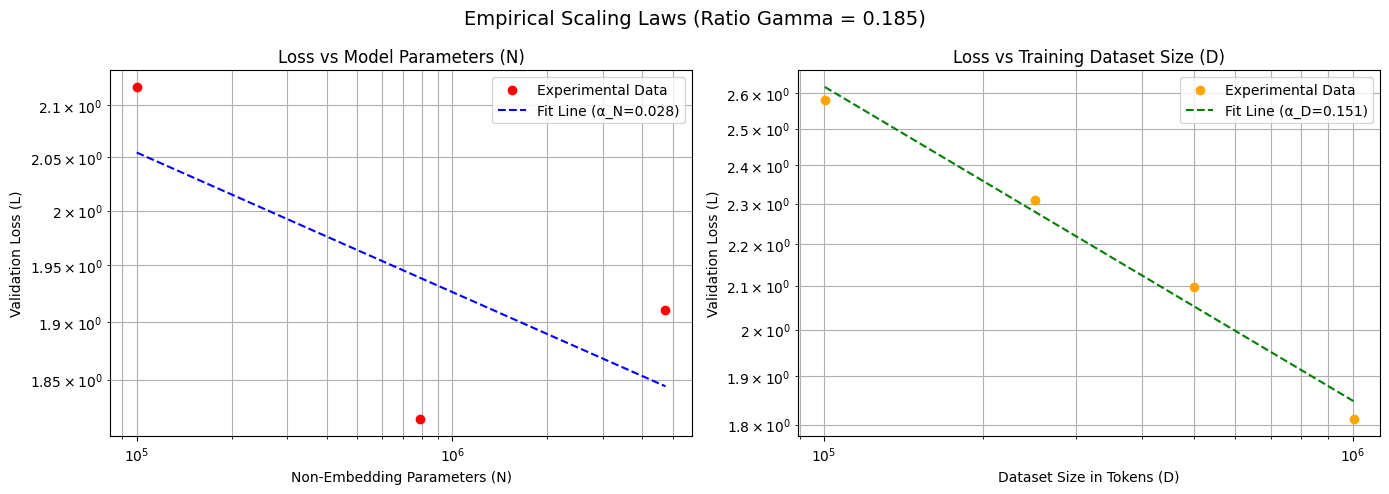

In [23]:
import train_scaling
import plot_scaling
import importlib

# Force reload the files to ensure all updates are active
importlib.reload(train_scaling)
importlib.reload(plot_scaling)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Starting Official Scaling sweeps (3,000 steps per configuration)...")
# 1. Run the official full length sweeps
train_scaling.run_sweeps(
    train_data=train_data,
    val_data=val_data,
    vocab_size=vocab_size,
    device=device,
    is_test_run=False # <-- OFFICIALLY SWEEPING FOR 3000 STEPS NOW
)

# 2. Run the plotting script to fit the lines and save scaling_laws.png
plot_scaling.generate_scaling_plots()